# Sustainable vs At-Risk Club Benchmarks

This notebook creates benchmark analysis for the slide:

> **Sustainable Club Benchmarks**

It compares **Sustainable** vs **At-Risk** non-Big-Six club-seasons and identifies practical benchmark ranges for sustainable Premier League performance.

Primary outputs:

- `benchmark_summary.csv`
- `benchmark_summary_deck_ready.csv`
- `benchmark_bar_chart.png`
- `benchmark_range_chart.png`

Recommended input:

`data/master/modelling_features.csv`

Default target:

`top_15_next_2_seasons`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("../data/master/modelling_features.csv")
OUTPUT_DIR = Path("../data/eda/benchmark_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Years:", sorted(df["year"].dropna().unique()))
df.head()


Shape: (180, 106)
Years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,team_id,team_name,understat_league,year,understat_season,matches,wins,draws,losses,scored,...,wage_efficiency_position,next_position,next_pts,next_npxGD,survived_next_season,top_15_next_season,mid_table_next_season,position_t_plus_2,survived_next_2_seasons,top_15_next_2_seasons
0,83,Arsenal,EPL,2016,2016/17,38,23,6,9,77,...,0.0,6.0,63.0,24.285193,1,1,0,5.0,1,1
1,83,Arsenal,EPL,2017,2017/18,38,19,6,13,74,...,-1.0,5.0,70.0,9.020181,1,1,0,8.0,1,1
2,83,Arsenal,EPL,2018,2018/19,38,21,7,10,73,...,0.0,8.0,56.0,-2.468798,1,1,1,8.0,1,1
3,83,Arsenal,EPL,2019,2019/20,38,14,14,10,56,...,-3.0,8.0,61.0,6.731510,1,1,1,5.0,1,1
4,83,Arsenal,EPL,2020,2020/21,38,18,7,13,55,...,-3.0,5.0,69.0,13.368984,1,1,0,2.0,1,1


## 1. Define sample and target

The main analysis excludes the Big Six so the benchmarks are more relevant to Sunderland's likely peer group.

The latest two seasons are excluded where the two-year future target cannot be reliably observed.


In [2]:
TARGET = "top_15_next_2_seasons"

required_cols = ["team_name", "year", "position", "big_six", TARGET]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

analysis_df = df[df["big_six"] == 0].copy()

max_observable_year = analysis_df["year"].max() - 2
analysis_df = analysis_df[analysis_df["year"] <= max_observable_year].copy()

analysis_df["stability_group"] = np.where(
    analysis_df[TARGET] == 1,
    "Sustainable",
    "At-Risk",
)

print("Analysis rows:", len(analysis_df))
print("Years used:", sorted(analysis_df["year"].unique()))
print(analysis_df["stability_group"].value_counts())


Analysis rows: 98
Years used: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
stability_group
At-Risk        51
Sustainable    47
Name: count, dtype: int64


## 2. Select benchmark metrics

These cover the areas in the brief:

- Underlying performance
- Defensive control
- Territory / possession proxy
- Financial indicators
- Wage/spend relationships
- Recruitment efficiency
- Squad characteristics
- Managerial stability


In [11]:
candidate_metrics = {
    "xG",
    "xGA",
    "npxGD",
    "oppda_coef",
    "wage_efficiency_npxGD",
    "net_spend_efficiency_npxGD",
}

metrics = [m for m in candidate_metrics if m in analysis_df.columns]


## 3. Benchmark table: Sustainable vs At-Risk

For each metric, calculate:

- Sustainable median
- At-Risk median
- Difference
- Sustainable 25th and 75th percentile range
- At-Risk 25th and 75th percentile range

For deck use, medians are usually better than means because the Premier League contains outliers.


In [13]:
rows = []

for metric in metrics:
    sustainable = analysis_df.loc[
        analysis_df["stability_group"] == "Sustainable", metric
    ].dropna()

    at_risk = analysis_df.loc[
        analysis_df["stability_group"] == "At-Risk", metric
    ].dropna()

    if len(sustainable) == 0 or len(at_risk) == 0:
        continue

    rows.append(
        {
            "metric": metric,
            "label": metric,
            "sustainable_n": len(sustainable),
            "at_risk_n": len(at_risk),
            "sustainable_median": sustainable.median(),
            "at_risk_median": at_risk.median(),
            "median_difference": sustainable.median() - at_risk.median(),
            "sustainable_p25": sustainable.quantile(0.25),
            "sustainable_p75": sustainable.quantile(0.75),
            "at_risk_p25": at_risk.quantile(0.25),
            "at_risk_p75": at_risk.quantile(0.75),
            "sustainable_mean": sustainable.mean(),
            "at_risk_mean": at_risk.mean(),
        }
    )

benchmark_summary = pd.DataFrame(rows)

priority_order = [
    "xG",
    "xGA",
    "npxGD",
    "oppda_coef",
    "wage_efficiency_npxGD",
    "net_spend_efficiency_npxGD",
]

benchmark_summary["metric_order"] = benchmark_summary["metric"].apply(
    lambda x: priority_order.index(x) if x in priority_order else 999
)

benchmark_summary = benchmark_summary.sort_values("metric_order").drop(columns="metric_order")
benchmark_summary.to_csv(OUTPUT_DIR / "benchmark_summary.csv", index=False)

benchmark_summary


,metric,label,sustainable_n,at_risk_n,sustainable_median,at_risk_median,median_difference,sustainable_p25,sustainable_p75,at_risk_p25,at_risk_p75,sustainable_mean,at_risk_mean
0,xG,xG,47,51,48.649836,41.880147,6.769689,41.290917,52.586422,36.914599,48.774818,48.056017,42.980400
2,xGA,xGA,47,51,53.535269,62.423162,-8.887893,49.946867,59.471642,53.527692,66.107208,54.649649,60.603675
1,npxGD,npxGD,47,51,-8.595568,-18.914064,10.318497,-16.941488,2.206977,-24.712208,-8.224628,-6.421521,-16.423374
3,oppda_coef,oppda_coef,47,51,9.564430,9.998761,-0.434331,8.748302,10.559805,8.993980,11.103607,9.915811,9.949751
5,wage_efficiency_npxGD,wage_efficiency_npxGD,47,51,0.000000,0.000000,0.000000,-2.500000,4.000000,-4.500000,3.000000,0.702128,-0.137255
4,net_spend_efficiency_npxGD,net_spend_efficiency_npxGD,47,51,0.000000,-4.000000,4.000000,-4.500000,4.000000,-7.500000,1.000000,-0.191489,-3.058824


## 4. Deck-ready benchmark table

This creates a smaller table for PowerPoint.

Use this on your **Sustainable Club Benchmarks** slide.


In [14]:
deck_metrics = [
    "xG",
    "xGA",
    "npxGD",
    "oppda_coef",
    "wage_efficiency_npxGD",
    "net_spend_efficiency_npxGD",
]

deck_table = benchmark_summary[
    benchmark_summary["metric"].isin(deck_metrics)
].copy()

deck_table = deck_table[
    [
        "metric",
        "label",
        "sustainable_median",
        "at_risk_median",
        "median_difference",
        "sustainable_p25",
        "sustainable_p75",
        "at_risk_p25",
        "at_risk_p75",
    ]
].copy()

for col in [
    "sustainable_median",
    "at_risk_median",
    "median_difference",
    "sustainable_p25",
    "sustainable_p75",
    "at_risk_p25",
    "at_risk_p75",
]:
    deck_table[col] = deck_table[col].round(2)

deck_table.to_csv(OUTPUT_DIR / "benchmark_summary_deck_ready.csv", index=False)

deck_table


,metric,label,sustainable_median,at_risk_median,median_difference,sustainable_p25,sustainable_p75,at_risk_p25,at_risk_p75
0,xG,xG,48.65,41.88,6.77,41.29,52.59,36.91,48.77
2,xGA,xGA,53.54,62.42,-8.89,49.95,59.47,53.53,66.11
1,npxGD,npxGD,-8.60,-18.91,10.32,-16.94,2.21,-24.71,-8.22
3,oppda_coef,oppda_coef,9.56,10.00,-0.43,8.75,10.56,8.99,11.10
5,wage_efficiency_npxGD,wage_efficiency_npxGD,0.00,0.00,0.00,-2.50,4.00,-4.50,3.00
4,net_spend_efficiency_npxGD,net_spend_efficiency_npxGD,0.00,-4.00,4.00,-4.50,4.00,-7.50,1.00


## 5. Bar chart: key sustainable vs at-risk benchmarks

This chart is designed for PowerPoint.  
It focuses on a small set of high-value metrics rather than trying to show everything.


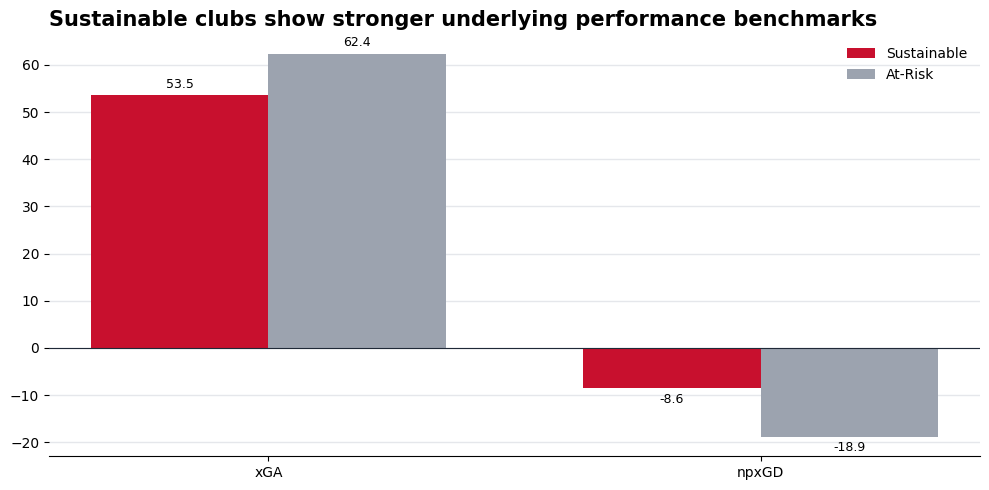

In [15]:
SUNDERLAND_RED = "#C8102E"
CHARCOAL = "#1F2937"
GREY = "#9CA3AF"
LIGHT_GREY = "#E5E7EB"

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

chart_metrics = ["npxGD", "xGA", "xpts", "deep_diff"]

chart_df = benchmark_summary[
    benchmark_summary["metric"].isin(chart_metrics)
].copy()

chart_df["short_label"] = chart_df["metric"].map(
    {
        "npxGD": "npxGD",
        "xGA": "xGA",
        "xpts": "xPts",
        "deep_diff": "Deep Diff",
    }
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(chart_df))
width = 0.36

ax.bar(
    x - width / 2,
    chart_df["sustainable_median"],
    width,
    label="Sustainable",
    color=SUNDERLAND_RED,
)

ax.bar(
    x + width / 2,
    chart_df["at_risk_median"],
    width,
    label="At-Risk",
    color=GREY,
)

ax.set_title("Sustainable clubs show stronger underlying performance benchmarks", loc="left")
ax.set_xticks(x)
ax.set_xticklabels(chart_df["short_label"])
ax.axhline(0, color=CHARCOAL, linewidth=0.8)
ax.grid(axis="y", color=LIGHT_GREY, linewidth=1)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(frameon=False, loc="best")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()


## 6. Range chart: sustainable benchmark ranges

This visual is good for explaining “thresholds” without pretending they are hard rules.

It shows the 25th to 75th percentile range for sustainable clubs.


In [ ]:
range_metrics = ["npxGD", "xGA", "xpts", "deep_diff", "wage_to_revenue", "avg_age"]

range_df = benchmark_summary[
    benchmark_summary["metric"].isin(range_metrics)
].copy()

range_df["short_label"] = range_df["metric"].map(
    {
        "npxGD": "npxGD",
        "xGA": "xGA",
        "xpts": "xPts",
        "deep_diff": "Deep Diff",
        "wage_to_revenue": "Wage/Revenue",
        "avg_age": "Avg Age",
    }
)

range_df["order"] = range_df["metric"].apply(lambda x: range_metrics.index(x))
range_df = range_df.sort_values("order")

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(range_df))

for i, row in enumerate(range_df.itertuples()):
    ax.plot(
        [row.sustainable_p25, row.sustainable_p75],
        [i, i],
        color=SUNDERLAND_RED,
        linewidth=6,
        solid_capstyle="round",
    )
    ax.scatter(
        row.sustainable_median,
        i,
        color=CHARCOAL,
        s=45,
        zorder=3,
    )

ax.set_yticks(y)
ax.set_yticklabels(range_df["short_label"])
ax.set_title("Sustainable club benchmark ranges", loc="left")
ax.grid(axis="x", color=LIGHT_GREY, linewidth=1)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "benchmark_range_chart.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. Suggested slide wording

### Header

**Sustainable clubs show stronger underlying process metrics, not just better league positions**

### Supporting copy

Compared with at-risk non-Big-Six clubs, sustainable clubs had stronger median non-penalty xG difference, lower xGA, higher expected points and better territory control. These are better treated as planning benchmarks than hard thresholds.

### Talk track

> Rather than treating sustainability as a single league position, I compared historical non-Big-Six club-seasons that achieved future stability against those that did not.  
> The strongest separation came from underlying performance indicators, especially non-penalty xG difference, xGA, expected points and deep completion differential.  
> I would treat these as benchmark ranges for SAFC: not guarantees, but useful indicators of whether the club is building repeatable Premier League performance.
